<h1> Libraries and Reproducibility</h1>

Import the required libraries for data processing, visualization, and deep learning. A fixed random seed is set across Python, NumPy, TensorFlow, and PyTorch to ensure reproducible results.

In [1]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import random
import tensorflow as tf
import torch

In [2]:
# Set seeds for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# PyTorch CPU & GPU
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Make CuDNN deterministic
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

<h1> Data Loading </h1>

Load the experimental datasets from pickle files. Some datasets are excluded.

In [3]:
path = Path.home() / "OneDrive - Université De Technologie De Belfort-Montbeliard" / "UTBM" / "Data" / "BQR_ALICE_data"
Df3 = pickle.load(open(path / "DF3.pkl", "rb"))
Df3=Df3.sort_values("tpstot(ms)") # sort the data

Df3= Df3.loc[~Df3.index.get_level_values(0).isin(Df3.index.get_level_values(0).unique()[12:18])]
Df3

heure    tpstot(ms)  tpsboucle(ms)  \
BQR_PM200_1_26092016_155309 0      15:53:09  6.604083e+06          224.0   
                            1      15:53:09  6.604376e+06          293.0   
                            2      15:53:10  6.604674e+06          298.0   
                            3      15:53:10  6.604976e+06          302.0   
                            4      15:53:10  6.605361e+06          385.0   
...                                     ...           ...            ...   
BQR_PM200_1_07102016_155314 58424  15:53:09  1.043404e+09          361.0   
                            58425  15:53:10  1.043405e+09          301.0   
                            58426  15:53:11  1.043407e+09          279.0   
                            58427  15:53:13  1.043408e+09          219.0   
                            58428  15:53:14  1.043410e+09          216.0   

                                      U1     U2     U3     U4     U5     U6  \
BQR_PM200_1_26092016_155309 0      0.949  0.942  0.957  0.954  0.959  0.954   
                            1      0.948  0.941  0.957  0.954  0.958  0.953   
                            2      0.948  0.941  0.957  0.954  0.958  0.953   
                            3      0.948  0.941  0.957  0.953  0.958  0.953   
                            4      0.942  0.935  0.950  0.947  0.951  0.947   
...                                  ...    ...    ...    ...    ...    ...   
BQR_PM200_1_07102016_155314 58424  0.847  0.847  0.846  0.845  0.846  0.845   
                            58425  0.859  0.859  0.858  0.858  0.858  0.858   
                            58426  0.872  0.871  0.871  0.870  0.871  0.871   
                            58427  0.887  0.886  0.886  0.886  0.886  0.886   
                            58428  0.915  0.914  0.915  0.915  0.915  0.915   

                                      U7  ...  Paircons  Psyncons  PH2cons  \
BQR_PM200_1_26092016_155309 0      0.947  ...       0.0       0.0      0.0   
                            1      0.947  ...       0.0       0.0      0.0   
                            2      0.947  ...       0.0       0.0      0.0   
                            3      0.946  ...       0.0       0.0      0.0   
                            4      0.940  ...       0.0       0.0      0.0   
...                                  ...  ...       ...       ...      ...   
BQR_PM200_1_07102016_155314 58424  0.846  ...       0.0       0.0      0.0   
                            58425  0.858  ...       0.0       0.0      0.0   
                            58426  0.871  ...       0.0       0.0      0.0   
                            58427  0.886  ...       0.0       0.0      0.0   
                            58428  0.916  ...       0.0       0.0      0.0   

                                   Z4338  TLCAircons  PIDeau  PIDair  PIDH2  \
BQR_PM200_1_26092016_155309 0        0.0        56.3     0.0     0.0 -4.507   
                            1        0.0        56.3     0.0     0.0 -4.394   
                            2        0.0        56.3     0.0     0.0 -4.507   
                            3        0.0        56.3     0.0     0.0 -4.279   
                            4        0.0        56.3     0.0     0.0 -4.242   
...                                  ...         ...     ...     ...    ...   
BQR_PM200_1_07102016_155314 58424    0.0        69.0     0.0     0.0  3.287   
                            58425    0.0        69.0     0.0     0.0  2.867   
                            58426    0.0        69.0     0.0     0.0  2.333   
                            58427    0.0        69.0     0.0     0.0  1.875   
                            58428    0.0        69.0     0.0     0.0  1.836   

                                   DeltaP  TbouAircons  
BQR_PM200_1_26092016_155309 0         0.0          NaN  
                            1         0.0          NaN  
                            2         0.0          NaN  
                            3         0.0          NaN  
     

<h1> Feature Selection </h1>

The analysis focuses on the following operational variables selected from the original dataset:

| Feature | Description |
|----------|------------|
| `tpstot(ms)` | Time |
| `TeH2` | Hydrogen inlet temperature |
| `TsH2` | Hydrogen outlet temperature |
| `TeAIR` | Air inlet temperature |
| `TsAIR` | Air outlet temperature |
| `TeEAU` | Water inlet temperature |
| `TsEAU` | Water outlet temperature |
| `PeAir` | Air inlet pressure |
| `PsAir` | Air outlet pressure |
| `PeH2` | Hydrogen inlet pressure |
| `PsH2` | Hydrogen outlet pressure |
| `DeH2` | Hydrogen inlet flow rate |
| `DsH2` | Hydrogen outlet flow rate |
| `DeAir` | Air inlet flow rate |
| `DsAir` | Air outlet flow rate |
| `Courant` | Stack current |
| `Deau` | Water flow rate |

In [4]:
Drop_cols = ['heure','tpsboucle(ms)',
             'U1', 'U2', 'U3', 'U4', 'U5', 'U6', 'U7', 'U8', 'U9', 'U10',
             'U11', 'U12', 'U13', 'U14', 'U15', 'U16', 'U17', 'U18', 'U19', 'U20',
             'Icons', 'TsatAircons', 'HrH2FC' , 'debeaucons', 'Tpilecons',  'TtraceH2cons',
             'Paircons', 'Psyncons', 'PH2cons', 'Z4338', 'PIDeau', 'PIDair', 'DeltaP',  'TbouAircons', 'Idyn', 'Imat', 'PIDH2',
             'HrH2','Ttracep', 'TsupcapH2', 'TvapoH2', 'Trech', 'THTBH2', 'Tbou', 'Tsat', 'Ttbousep', 'HrAirFC', 'TLCAircons',
             'TbouH2cons', 'Ttracehy', 'TBSBH2', 'HrAir', 'TcolH2', 'DeauH2', 'niveauBH2']


Df3 = Df3.drop(columns=Drop_cols)

## Raw Signal Visualization

Visualize the voltage (`Upile`) and current (`Courant`) signals for an example test case before preprocessing.

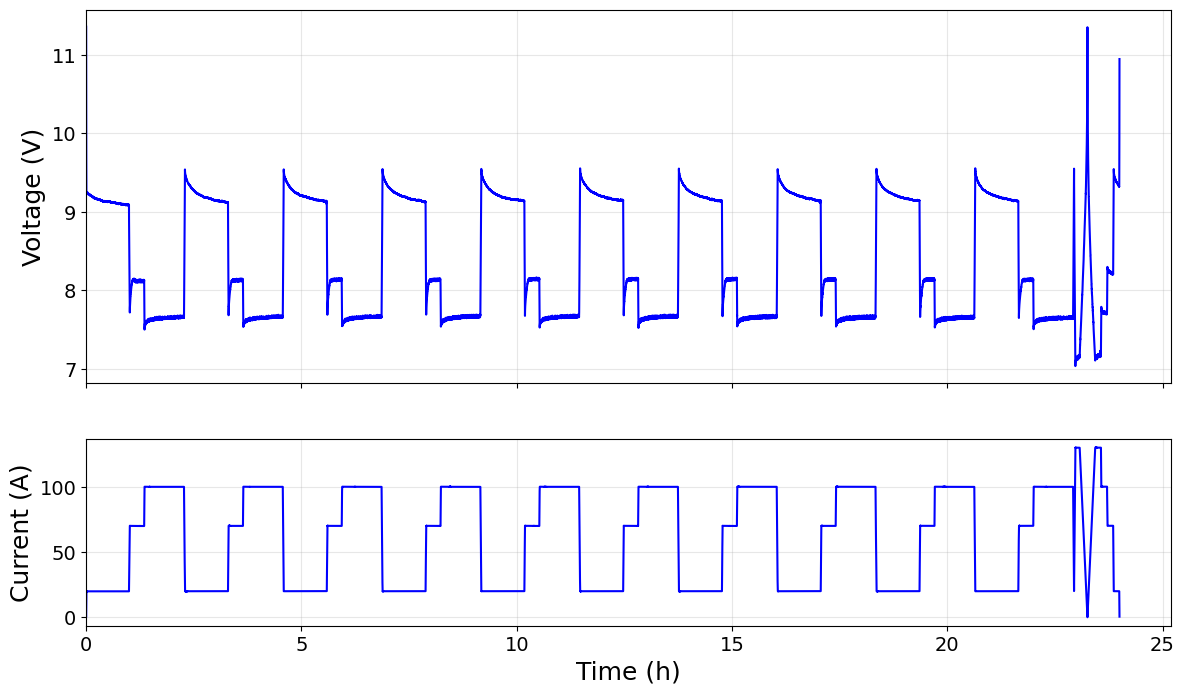

In [5]:
i=0
#plt.style.use("seaborn-v0_8-darkgrid")
fig, ax = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1], sharex=True)
t = (Df3.loc[Df3.index.get_level_values(0).unique()[i]]["tpstot(ms)"] - Df3.loc[Df3.index.get_level_values(0).unique()[i]]["tpstot(ms)"].iloc[0]) / (1000*60*60)
ax[0].plot (t, Df3.loc[Df3.index.get_level_values(0).unique()[i]]["Upile"],color='blue')
ax[0].set_ylabel("Voltage (V)", size=18)
#ax[0].set_title("Test Case 1", size=20)
ax[1].plot(t, Df3.loc[Df3.index.get_level_values(0).unique()[i]]["Courant"], color='blue')
ax[1].set_ylabel("Current (A)", size=18)
ax[1].set_xlabel("Time (h)", size=18)
ax[0].tick_params(axis='both', colors='black', labelsize=14)
ax[1].tick_params(axis='both', colors='black', labelsize=14)
ax[0].grid(True, alpha=0.3)
ax[1].grid(True, alpha=0.3)
ax[0].set_xlim(left=0)
ax[1].set_xlim(left=0)
plt.savefig("Alice_sig1.pdf", format='pdf', bbox_inches='tight')

#plt.savefig( "Alice_sig1.png", dpi=600, bbox_inches="tight", facecolor="white")
#plt.savefig("Alice_sig1.png", dpi=300, bbox_inches="tight", facecolor="white")
#plt.savefig("Alice_sig1.eps", format='eps', bbox_inches='tight')
plt.show()
plt.style.use("default")


## Data Resampling

To reduce computational cost and accelerate model training, the raw time-series data is resampled every 30 seconds. This preprocessing step decreases the number of samples while preserving the overall system dynamics and trends.

In [6]:
def DfResampling(df, simpTime):
    Df=df.copy()
    Df = Df.reset_index()
    Df = Df.drop(columns=["level_1"])
    Df['tpstot(ms)'] = pd.to_datetime(Df['tpstot(ms)'], unit='ms')
    Df = Df.set_index('tpstot(ms)')
    
    num_cols = Df.select_dtypes(include='number').columns
    str_cols = Df.select_dtypes(include='object').columns
    Df = Df.resample(simpTime).agg({
        **{c: 'mean' for c in num_cols},
        **{c: 'first' for c in str_cols}})

    Df=Df.reset_index()
    Df['tpstot(ms)'] = Df['tpstot(ms)'].view('int64') / 1_000_000
    Df['step'] = Df.groupby('level_0').cumcount()
    Df = Df.set_index(['level_0', 'step'])
    return Df

NDf3 = DfResampling(Df3, '30s')
NDf3

C:\Users\abraydi\AppData\Local\Temp\ipykernel_19108\2093593537.py:15: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  Df['tpstot(ms)'] = Df['tpstot(ms)'].view('int64') / 1_000_000


tpstot(ms)       TeH2       TsH2  \
level_0                     step                                       
BQR_PM200_1_26092016_155309 0     6.600000e+06  23.658241  34.401759   
                            1     6.630000e+06  23.333273  34.210222   
                            2     6.660000e+06  23.244396  33.997644   
                            3     6.690000e+06  23.237710  33.825290   
                            4     6.720000e+06  23.256840  33.700160   
...                                        ...        ...        ...   
BQR_PM200_1_07102016_155314 2875  1.043280e+09  24.927050  36.090200   
                            2876  1.043310e+09  24.939900  35.940950   
                            2877  1.043340e+09  24.956700  35.782150   
                            2878  1.043370e+09  24.967500  35.629800   
                            2879  1.043400e+09  24.992857  35.845286   

                                      TeAIR      TsAIR      TeEAU      TsEAU  \
level_0                     step                                               
BQR_PM200_1_26092016_155309 0     22.717253  41.929874  52.545793  52.087103   
                            1     22.712667  42.432808  52.333424  52.284737   
                            2     22.694139  42.532871  52.257802  52.156723   
                            3     22.680820  42.503510  52.233940  52.105640   
                            4     22.673510  42.492990  52.190210  52.054860   
...                                     ...        ...        ...        ...   
BQR_PM200_1_07102016_155314 2875  23.403150  44.657850  53.291450  53.117150   
                            2876  23.394800  44.488350  53.181800  53.039450   
                            2877  23.386950  44.323950  53.106300  52.971950   
                            2878  23.377300  44.169650  53.049650  52.882950   
                            2879  23.371286  44.104571  53.017714  52.575286   

                                        PeAir        PsAir         PeH2  \
level_0                     step                                          
BQR_PM200_1_26092016_155309 0     1011.311966   999.767103  1003.152195   
                            1     1014.364374  1001.643697  1000.333172   
                            2     1014.447030  1002.159515  1000.567317   
                            3     1014.755810  1002.459340  1000.649540   
                            4     1015.147530  1002.477580  1000.947360   
...                                       ...          ...          ...   
BQR_PM200_1_07102016_155314 2875   992.151750   978.528700   984.455450   
                            2876   992.489150   978.547700   984.206050   
                            2877   992.009500   978.429950   984.508750   
                            2878   992.337600   978.636800   985.321400   
                            2879   994.410286   980.097429   991.446000   

                                        PsH2      DeH2      DsH2     DeAir  \
level_0                     step                                             
BQR_PM200_1_26092016_155309 0     981.196023  4.145471 -7.498989  9.206793   
                            1     979.141848  4.405949 -7.499000  9.851030   
                            2     979.209386  4.407000 -7.498990  9.854584   
                            3     979.250210  4.409670 -7.499000  9.843650   
                            4     979.190000  4.408820 -7.499000  9.859010   
...                                      ...       ...       ...       ...   
BQR_PM200_1_07102016_155314 2875  965.881550  4.279550 -7.499000  9.418550   
                            2876  965.678250  4.280750 -7.499000  9.430650   
                            2877  965.653550  4.279700 -7.499000  9.418000   
                            2878  966.018200  4.280500 -7.499000  9.434000   
                            2879  969.529000  4.284571 -7.499000  9.434286   

                                     DsAir    Courant      Upile   

## Preprocessing Comparison (One Day)

Comparison of the original and resampled signals for a representative one-day period, showing that the 30-second resampling preserves the overall signal behavior while reducing the number of samples.

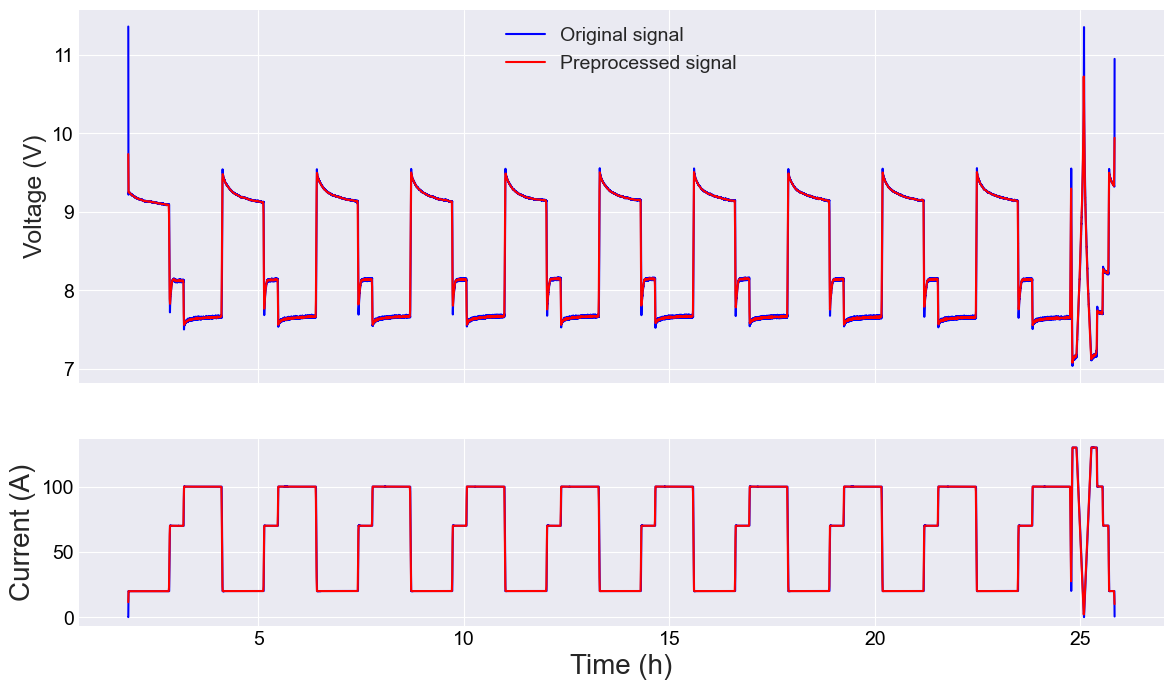

In [7]:
i=0
plt.style.use("seaborn-v0_8-darkgrid")
fig, ax = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1], sharex=True)
ax[0].plot (Df3.loc[Df3.index.get_level_values(0).unique()[i]]["tpstot(ms)"]/(1000*60*60), Df3.loc[Df3.index.get_level_values(0).unique()[i]]["Upile"],color='blue', label='Original signal')
ax[0].plot (NDf3.loc[NDf3.index.get_level_values(0).unique()[i]]["tpstot(ms)"]/(1000*60*60), NDf3.loc[NDf3.index.get_level_values(0).unique()[i]]["Upile"],color='red', label='Preprocessed signal')
ax[0].set_ylabel("Voltage (V)", size=18)
#ax[0].set_title("Test Case 1", size=18)
ax[1].plot(Df3.loc[Df3.index.get_level_values(0).unique()[i]]["tpstot(ms)"]/(1000*60*60), Df3.loc[Df3.index.get_level_values(0).unique()[i]]["Courant"], color='blue', label='Original signal')
ax[1].plot(NDf3.loc[NDf3.index.get_level_values(0).unique()[i]]["tpstot(ms)"]/(1000*60*60), NDf3.loc[NDf3.index.get_level_values(0).unique()[i]]["Courant"], color='red', label='Preprocessed signal')
ax[1].set_ylabel("Current (A)", size=20)
ax[1].set_xlabel("Time (h)", size=20)
ax[0].tick_params(axis='both', colors='black', labelsize=14)
ax[1].tick_params(axis='both', colors='black', labelsize=14)
ax[0].legend(fontsize=14)
#plt.savefig("ALICE_1_Preprocessing.pdf", format='pdf', bbox_inches='tight')
#plt.savefig("ALICE_1_Preprocessing.png", dpi=600, bbox_inches="tight", facecolor="white")
plt.show()
plt.style.use("default")

## Global Signal Overview

Visualize the original and resampled voltage and current signals over the entire dataset.

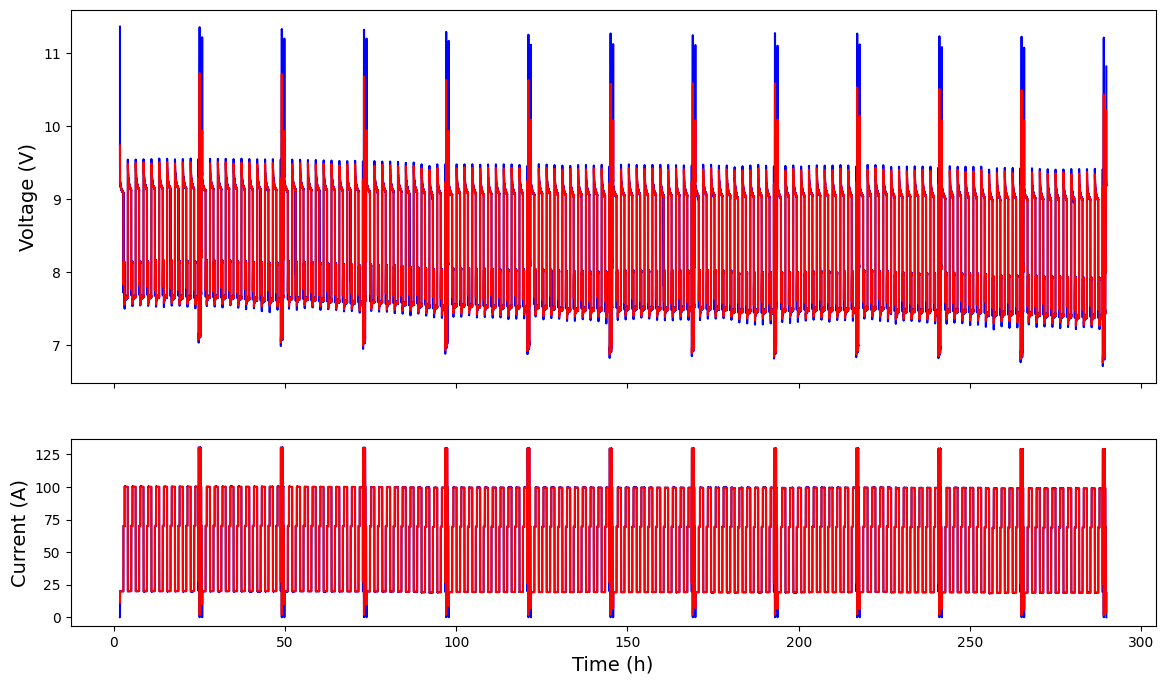

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1], sharex=True)
ax[0].plot (Df3["tpstot(ms)"]/(1000*60*60), Df3["Upile"],color='blue')
ax[0].plot (NDf3["tpstot(ms)"]/(1000*60*60), NDf3["Upile"],color='red')
ax[0].set_ylabel("Voltage (V)", size=14)
ax[1].plot(Df3["tpstot(ms)"]/(1000*60*60), Df3["Courant"], color='blue')
ax[1].plot(NDf3["tpstot(ms)"]/(1000*60*60), NDf3["Courant"], color='red')
ax[1].set_ylabel("Current (A)", size=14)
ax[1].set_xlabel("Time (h)", size=14)
plt.show()

## Train-Test Split

Split the dataset into training (70%) and testing (30%) subsets while preserving the temporal order of the measurements.

In [9]:
Trate = 0.7

Train = NDf3.iloc[0:int(len(NDf3)*Trate)]

Test = NDf3.iloc[int(len(NDf3)*Trate):]

print(len(Train), len(Test))
X_tr = Train.drop(columns=["Upile"]).values
Y_tr = Train ["Upile"].values.reshape(-1, 1)

X_ts = Test.drop(columns=["Upile"]).values
Y_ts = Test ["Upile"].values.reshape(-1, 1)

24192 10369


## Data Normalization

Normalize the input features and target variable using Min-Max scaling. The scalers are fitted on the training set and then applied to the test set to avoid data leakage.

The normalized inputs are finally reshaped into the format required by the deep learning models.

In [10]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
X_tr_scaled = scaler_x.fit_transform(X_tr)
X_ts_scaled = scaler_x.transform(X_ts)

Ytr = scaler_y.fit_transform(Y_tr)
Yts = scaler_y.transform(Y_ts)

Xtr = X_tr_scaled.reshape(X_tr_scaled.shape[0], 1, 17)
Xts= X_ts_scaled.reshape(X_ts_scaled.shape[0], 1, 17)

## LSTM-self-attention Model

Hybrid architecture combining LSTM layers and self-attention for voltage prediction.

In [11]:
import torch.nn as nn

# Model Definition
class LSTM_TF(nn.Module):
    def __init__(self, input_dim, seq_len):
        super(LSTM_TF, self).__init__()

        self.seq_len = seq_len

        # ----- Step 1: LSTM block -----
        self.lstm1 = nn.LSTM(
            input_size=input_dim,
            hidden_size=64,
            batch_first=True,
            num_layers=1
        )

        self.lstm2 = nn.LSTM(
            input_size=64,
            hidden_size=64,
            batch_first=True,
            num_layers=1
        )

        # ----- Step 2: Multi-head self-attention -----
        # PyTorch MHA uses "embed_dim" = num_heads * head_dim
        embed_dim = 64  # 32*8
        self.attention_proj = nn.Linear(input_dim, embed_dim)

        self.mha = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=4,
            dropout=0,
            batch_first=True
        )

        # Concatenated dimension =  256 + 192
        self.post_cat_dim = 64 + embed_dim 

        # ----- Step 3–4: Dense layers -----
        self.fc1 = nn.Linear(self.post_cat_dim, 64)
        self.dropout = nn.Dropout(0.4)
        self.out = nn.Linear(64, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)

        # ----- LSTM block -----
        x1, _ = self.lstm1(x)  # (B, L, 256)
        x1, _ = self.lstm2(x1) # (B, L, 256)

        # ----- Transformer block -----
        attn_input = self.attention_proj(x)  # (B, L, 192)
        attn_output, _ = self.mha(attn_input, attn_input, attn_input)

        # Concatenate features along last axis
        x_cat = torch.cat([x1, attn_output], dim=-1)  # (B, L, 448)

        # Flatten
        x_pool = torch.mean(x_cat, dim=1)

        # Dense layers
        x_dense = torch.relu(self.fc1(x_pool))
        x_dense = self.dropout(x_dense)

        return self.out(x_dense)

In [12]:
# Model Summary
seq_len  = Xtr.shape[1]
input_dim = Xtr.shape[2]

model = LSTM_TF(input_dim=input_dim, seq_len=seq_len)
print(model)

from torchinfo import summary
summary(model, input_size=(1, seq_len, input_dim))

LSTM_TF(
  (lstm1): LSTM(17, 64, batch_first=True)
  (lstm2): LSTM(64, 64, batch_first=True)
  (attention_proj): Linear(in_features=17, out_features=64, bias=True)
  (mha): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
  )
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (out): Linear(in_features=64, out_features=1, bias=True)
)


Layer (type:depth-idx)                   Output Shape              Param #
LSTM_TF                                  [1, 1]                    --
├─LSTM: 1-1                              [1, 1, 64]                21,248
├─LSTM: 1-2                              [1, 1, 64]                33,280
├─Linear: 1-3                            [1, 1, 64]                1,152
├─MultiheadAttention: 1-4                [1, 1, 64]                16,640
├─Linear: 1-5                            [1, 64]                   8,256
├─Dropout: 1-6                           [1, 64]                   --
├─Linear: 1-7                            [1, 1]                    65
Total params: 80,641
Trainable params: 80,641
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.06
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.26
Estimated Total Size (MB): 0.26

## Training Setup

Create PyTorch datasets and dataloaders, then define the loss function, optimizer, and learning rate scheduler.

In [13]:
from torch.utils.data import TensorDataset, DataLoader
Xtr_torch = torch.tensor(Xtr, dtype=torch.float32)
Ytr_torch = torch.tensor(Ytr, dtype=torch.float32)

Xts_torch = torch.tensor(Xts, dtype=torch.float32)
Yts_torch = torch.tensor(Yts, dtype=torch.float32)

# Create datasets
train_dataset = TensorDataset(Xtr_torch, Ytr_torch)
test_dataset  = TensorDataset(Xts_torch, Yts_torch)

BATCH_SIZE= 32
# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

In [14]:
criterion = torch.nn.L1Loss()  # MAE: L1
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# LR scheduler equivalent to ReduceLROnPlateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=4,
    min_lr=1e-6
)

## Model Training

Train the LSTM-self-attention model and monitor the training and validation losses over multiple epochs.

In [15]:
device = torch.device("cuda")
model.to(device)

EPOCHS = 15
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---- Validation -----
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for Xv, yv in test_loader:
            Xv = Xv.to(device)
            yv = yv.to(device)

            pv = model(Xv)
            lv = criterion(pv, yv)

            val_loss += lv.item()

    val_loss /= len(test_loader)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} — train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

Epoch 1/15 — train_loss=0.0540 | val_loss=0.0195
Epoch 2/15 — train_loss=0.0291 | val_loss=0.0155
Epoch 3/15 — train_loss=0.0272 | val_loss=0.0164
Epoch 4/15 — train_loss=0.0266 | val_loss=0.0140
Epoch 5/15 — train_loss=0.0265 | val_loss=0.0099
Epoch 6/15 — train_loss=0.0263 | val_loss=0.0126
Epoch 7/15 — train_loss=0.0259 | val_loss=0.0091
Epoch 8/15 — train_loss=0.0259 | val_loss=0.0065
Epoch 9/15 — train_loss=0.0257 | val_loss=0.0211
Epoch 10/15 — train_loss=0.0253 | val_loss=0.0197
Epoch 11/15 — train_loss=0.0253 | val_loss=0.0060
Epoch 12/15 — train_loss=0.0251 | val_loss=0.0079
Epoch 13/15 — train_loss=0.0250 | val_loss=0.0125
Epoch 14/15 — train_loss=0.0252 | val_loss=0.0141
Epoch 15/15 — train_loss=0.0248 | val_loss=0.0095


## Prediction Visualization

Generate model predictions, transform them back to the original voltage scale, and compare them with the experimental data.

In [16]:
def plot_pytorch(df, ln_tr, pred_train, pred_test, name="LSTM_CNN", save_name="name", title="title"):

    # ----- Plot -----
    plt.figure(figsize=(12, 5))

    # Experimental data
    plt.scatter(df["tpstot(ms)"]/(1000*60*60), df['Upile'], facecolors='none', edgecolors='blue', s=1, label='Experimental data')

    # Train predictions
    plt.plot( df[:ln_tr]["tpstot(ms)"]/(1000*60*60), pred_train, color='red', label=name + ' (Train)')

    # Test predictions
    plt.plot( df[ln_tr:]["tpstot(ms)"]/(1000*60*60), pred_test, color='green', label=name + ' (Test)')

    # Mark training region
    split_time = df["tpstot(ms)"].iloc[ln_tr]/(1000*60*60)
    plt.axvspan(df["tpstot(ms)"].iloc[0]/(1000*60*60), split_time, color='gray', alpha=0.1, label='Training region')

    plt.xlabel("Time (h)", fontsize=12)
    plt.ylabel("Voltage (V)", fontsize=12)
    plt.title("Fuel Cell Voltage Degradation – " + title, fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
#   plt.savefig(save_name + ".pdf", format='pdf', bbox_inches='tight')
    plt.show()

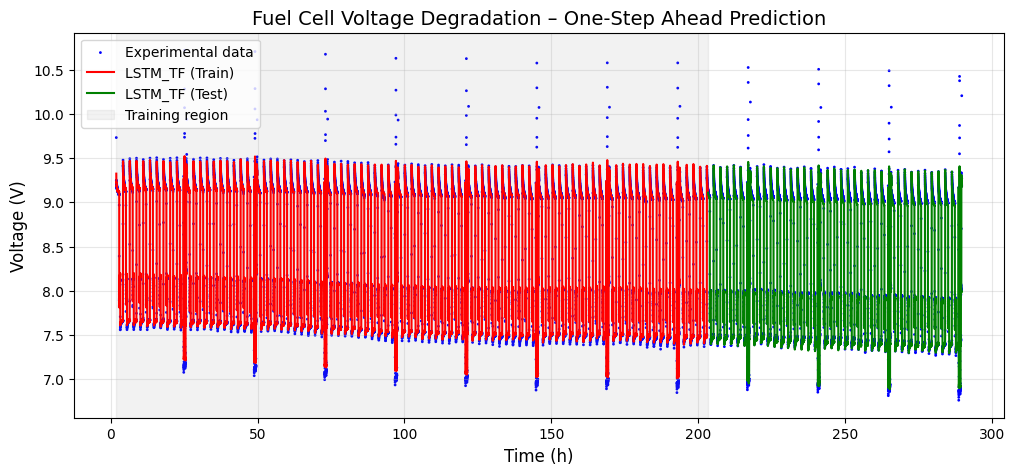

In [17]:
device = torch.device("cpu")
model = model.to(device)
model.eval()
Xtrain_torch = torch.tensor(Xtr, dtype=torch.float32).to(device)
Xtest_torch = torch.tensor(Xts, dtype=torch.float32).to(device)

with torch.no_grad():
    pred_train = model(Xtrain_torch).cpu().numpy()
    pred_test = model(Xtest_torch).cpu().numpy()

pred_train = scaler_y.inverse_transform(pred_train)
pred_test = scaler_y.inverse_transform(pred_test)

plot_pytorch( NDf3, len(Xtr), pred_train, pred_test, name="LSTM_TF", save_name="BZ100_1_LSTM_TF_1step",
              title="One-Step Ahead Prediction")

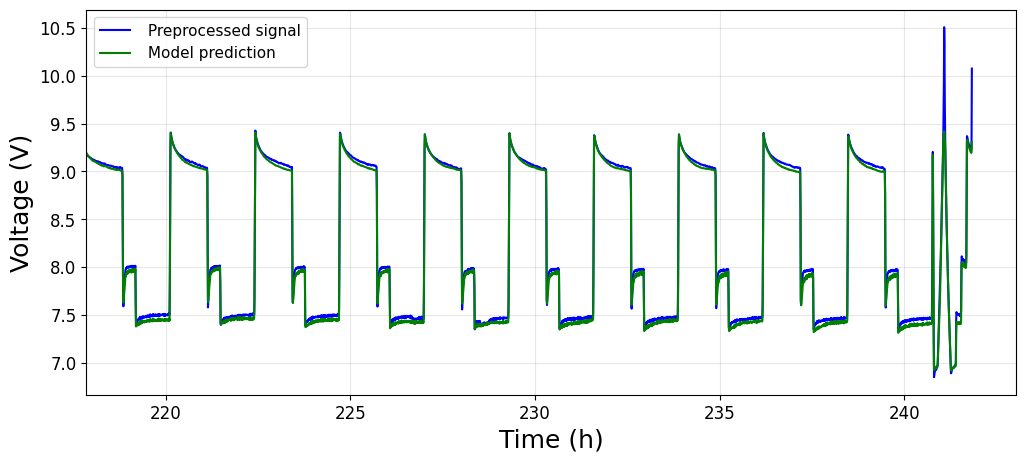

In [18]:
i=9
plt.figure(figsize=(12, 5))

plt.plot( NDf3.loc[NDf3.index.get_level_values(0).unique()[i]]["tpstot(ms)"]/(1000*60*60), NDf3.loc[NDf3.index.get_level_values(0).unique()[i]]['Upile'], color='blue', label=' Preprocessed signal')
plt.plot( NDf3[len(Xtr):][1730:4609]["tpstot(ms)"]/(1000*60*60), pred_test[1730:4609], color='green', label=' Model prediction')
plt.xlabel("Time (h)", fontsize=18)
plt.ylabel("Voltage (V)", fontsize=18)
plt.tick_params(axis='both', colors='black', labelsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.xlim(left=(NDf3.loc[NDf3.index.get_level_values(0).unique()[i]]["tpstot(ms)"]/(1000*60*60)).iloc[0])
#plt.savefig("Alice_1_LSTMATTn_pred1c.png", dpi=600, bbox_inches="tight", facecolor="white")
#plt.savefig("Alice_1_LSTMATTn_pred1c.pdf", format='pdf', bbox_inches='tight')
#plt.savefig("Alice_1_LSTMATTn_pred1c.eps", format='pdf', bbox_inches='tight')
plt.show()

## Model Evaluation

Evaluate the model performance on the training and test sets using MSE, RMSE, MAE, and R² metrics.

In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def regression_metrics(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

y_train_true = NDf3[: len(Xtr)]['Upile']   # or whatever your true training target is
y_train_pred = pred_train

mse_tr, rmse_tr, mae_tr, r2_tr = regression_metrics(y_train_true, y_train_pred)

print("TRAINING METRICS")
print(f"MSE  : {mse_tr:.4f}")
print(f"RMSE : {rmse_tr:.4f}")
print(f"MAE  : {mae_tr:.4f}")
print(f"R²   : {r2_tr:.4f}")

TRAINING METRICS
MSE  : 0.0015
RMSE : 0.0382
MAE  : 0.0160
R²   : 0.9975


In [20]:
y_test_true = NDf3[len(Xtr):]['Upile']



mse_LT, rmse_LT, mae_LT, r2_LT = regression_metrics(y_test_true, pred_test)

print("\nLong term prediction")
print(f"MSE  : {mse_LT:.4f}")
print(f"RMSE : {rmse_LT:.4f}")
print(f"MAE  : {mae_LT:.4f}")
print(f"R²   : {r2_LT:.4f}")


Long term prediction
MSE  : 0.0028
RMSE : 0.0528
MAE  : 0.0341
R²   : 0.9955


## Sensitivity Analysis

Perform FAST sensitivity analysis to quantify the influence of each input feature on the model prediction.

In [21]:
from SALib.sample import fast_sampler
from SALib.analyze import fast

In [22]:
feature_names = Train.drop(columns=["Upile"]).columns.tolist()
problem = {
    "num_vars": len(feature_names),
    "names": feature_names,
    # because you MinMaxScaled -> bounds in scaled space are [0, 1]
    "bounds": [[0.0, 1.0]] * len(feature_names)
}

N = 1024
M = 4
X_fast = fast_sampler.sample(problem, N, M=M)

model.eval()
device = next(model.parameters()).device

@torch.no_grad()
def predict_scaled_y(X_np, batch_size=4096):
    """
    X_np: (N, 38) in scaled space [0,1]
    returns: (N,) predictions in scaled Y space (because model trained on Ytr)
    """
    preds = []
    n = X_np.shape[0]
    for i in range(0, n, batch_size):
        xb = torch.tensor(X_np[i:i+batch_size], dtype=torch.float32, device=device)
        xb = xb.view(xb.shape[0], 1, xb.shape[1])  # (B, seq_len=1, 38)
        yb = model(xb).squeeze(-1)                 # (B,)
        preds.append(yb.detach().cpu().numpy())
    return np.concatenate(preds, axis=0)

Y_fast_scaled = predict_scaled_y(X_fast)

Y_fast = Y_fast_scaled

Si = fast.analyze(problem, Y_fast, M=M, print_to_console=True)

                  S1        ST   S1_conf   ST_conf
tpstot(ms)  0.010109  0.011971  0.016647  0.041246
TeH2        0.032632  0.034670  0.014813  0.046350
TsH2        0.002974  0.004857  0.015210  0.044210
TeAIR       0.018766  0.021355  0.015011  0.041478
TsAIR       0.050069  0.054121  0.015138  0.040480
TeEAU       0.012759  0.014909  0.013398  0.044490
TsEAU       0.001707  0.003505  0.014109  0.040073
PeAir       0.055710  0.060354  0.016404  0.035824
PsAir       0.013632  0.015658  0.011460  0.036979
PeH2        0.001312  0.003313  0.017984  0.040196
PsH2        0.024196  0.026808  0.014245  0.035209
DeH2        0.230616  0.247754  0.015152  0.045196
DsH2        0.000573  0.002450  0.014190  0.038284
DeAir       0.210772  0.225346  0.016342  0.044359
DsAir       0.071655  0.078277  0.015900  0.040626
Courant     0.240302  0.256298  0.015902  0.044766
Deau        0.000002  0.000942  0.013608  0.034419


In [23]:
df_S = pd.DataFrame({
    "feature": feature_names,
    "S1": Si["S1"],
    "ST": Si["ST"],
}).sort_values("ST", ascending=False)

display(df_S.head(20))

,feature,S1,ST
15,Courant,0.240302,0.256298
11,DeH2,0.230616,0.247754
13,DeAir,0.210772,0.225346
14,DsAir,0.071655,0.078277
7,PeAir,0.055710,0.060354
4,TsAIR,0.050069,0.054121
1,TeH2,0.032632,0.034670
10,PsH2,0.024196,0.026808
3,TeAIR,0.018766,0.021355
8,PsAir,0.013632,0.015658


## Sensitivity Indices

Display and visualize the first-order (`S1`) and total-order (`ST`) sensitivity indices for all input features.

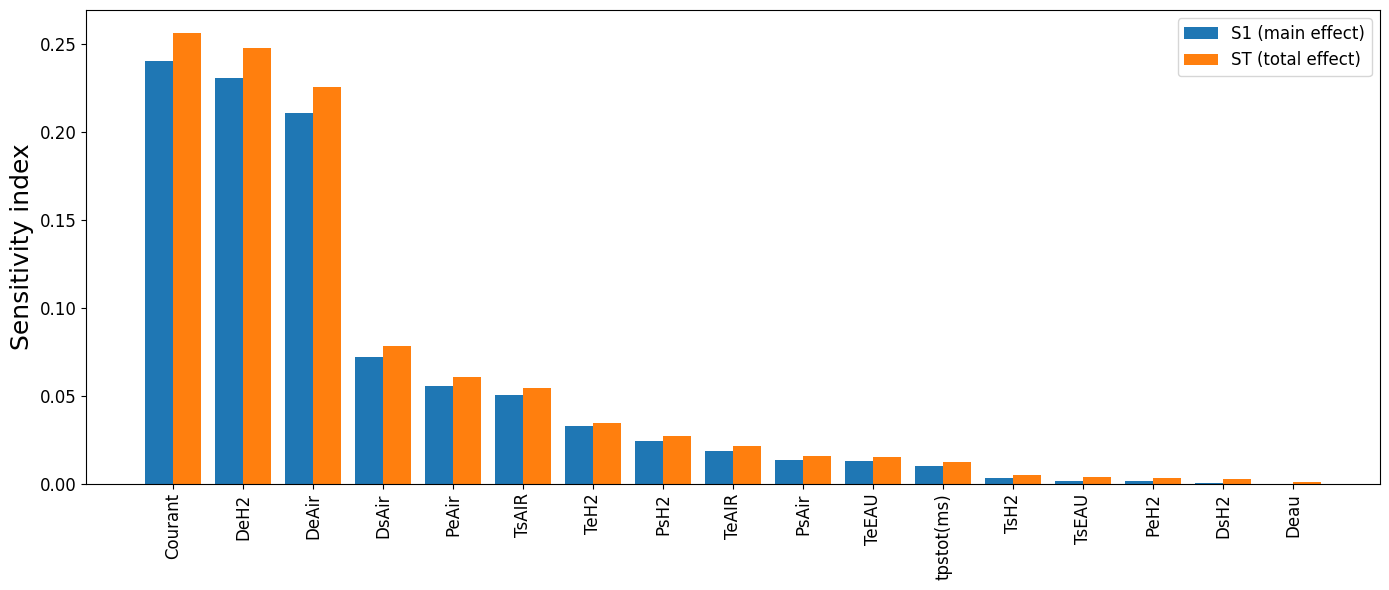

In [24]:
df_plot = df_S.sort_values("ST", ascending=False)
x = np.arange(len(df_plot))
width = 0.4

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, df_plot["S1"], width, label="S1 (main effect)")
plt.bar(x + width/2, df_plot["ST"], width, label="ST (total effect)")

plt.xticks(x, df_plot["feature"], rotation=90, fontsize=18)
plt.ylabel("Sensitivity index", fontsize=18)
plt.tick_params(axis='both', colors='black', labelsize=12)
#plt.title("FAST Sensitivity Analysis – S1 vs ST")
plt.legend(fontsize=12)
plt.tight_layout()
#plt.savefig("Alice_1_SA.png", dpi=600, bbox_inches="tight", facecolor="white")
#plt.savefig("Alice_1_SA.pdf", format='pdf', bbox_inches='tight')
#plt.savefig("Alice_1_SA.eps", format='pdf', bbox_inches='tight')
plt.show()

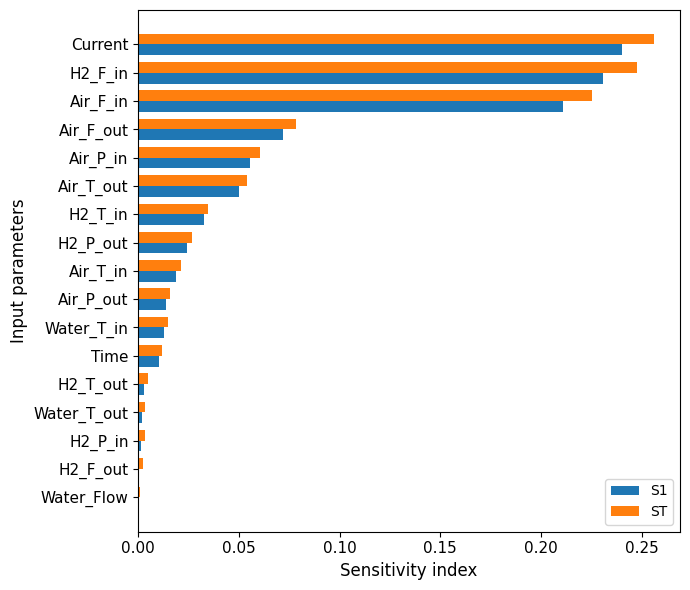

In [25]:
short_names = {
    "tpstot(ms)": "Time",
    "TeH2": "H2_T_in",
    "TsH2": "H2_T_out",
    "TeAIR": "Air_T_in",
    "TsAIR": "Air_T_out",
    "TeEAU": "Water_T_in",
    "TsEAU": "Water_T_out",
    "PeAir": "Air_P_in",
    "PsAir": "Air_P_out",
    "PeH2": "H2_P_in",
    "PsH2": "H2_P_out",
    "DeH2": "H2_F_in",
    "DsH2": "H2_F_out",
    "DeAir": "Air_F_in",
    "DsAir": "Air_F_out",
    "Courant": "Current",
    "Deau": "Water_Flow"
}


df_S = pd.DataFrame({
    "feature": feature_names,
    "feature_short": [short_names.get(f, f) for f in feature_names],
    "S1": Si["S1"],
    "ST": Si["ST"],
}).sort_values("ST", ascending=True)

# Optional: keep only top 15 for a cleaner one-column figure
df_plot = df_S.tail(17)

y = np.arange(len(df_plot))
bar_h = 0.38

plt.figure(figsize=(7, 6))  # good for one-column paper
plt.barh(y - bar_h/2, df_plot["S1"], height=bar_h, label="S1")
plt.barh(y + bar_h/2, df_plot["ST"], height=bar_h, label="ST")

plt.yticks(y, df_plot["feature_short"], fontsize=11)
plt.xlabel("Sensitivity index", fontsize=12)
plt.ylabel("Input parameters", fontsize=12)
plt.tick_params(axis='both', colors='black', labelsize=11)
plt.legend(fontsize=10, loc="lower right")
plt.tight_layout()

#plt.savefig("Alice_1_SA_horizontal.eps", format="eps", bbox_inches="tight")
#plt.savefig("Alice_1_SA_horizontal.pdf", format="pdf", bbox_inches="tight")
plt.show()

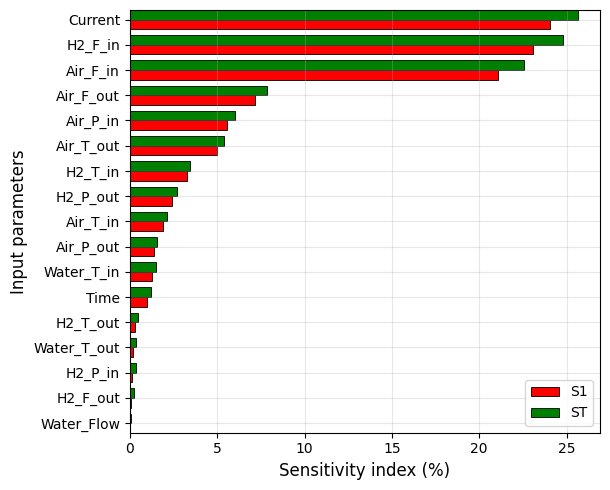

In [26]:
df_S = df_S.sort_values("ST", ascending=False).reset_index(drop=True)
plt.style.use("default")
top_n = 17
df_top = df_S.iloc[:top_n].copy()
df_rest = df_S.iloc[top_n:].copy()


# Append "Other" at the end
df_plot = pd.concat([df_top], ignore_index=True)

# Reverse ONLY for horizontal plotting so the first item appears on top
df_plot_plot = df_plot.iloc[::-1].reset_index(drop=True)

y = np.arange(len(df_plot_plot))
bar_h = 0.38



plt.figure(figsize=(6.2, 5))
plt.margins(y=0)
plt.grid(True, alpha=0.3)
plt.barh(y - bar_h/2, df_plot_plot["S1"]*100, height=bar_h, label="S1", color='red', edgecolor="black", linewidth=0.6)
plt.barh(y + bar_h/2, df_plot_plot["ST"]*100, height=bar_h, label="ST", color='green', edgecolor="black", linewidth=0.6)

plt.yticks(y, df_plot_plot["feature_short"], fontsize=10)
plt.xlabel("Sensitivity index (%)", fontsize=12)
plt.ylabel("Input parameters", fontsize=12)
plt.legend(fontsize=10, loc="lower right")
plt.tight_layout()
#plt.savefig("Alice_SA_art.pdf", format='pdf', bbox_inches='tight')
plt.show()